In [1]:
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else skill_list)

c:\Users\Ryan\anaconda3\envs\pyp\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

# data = {
#     'job_skills': ['python', 'sql', 'java', 'c++', 'c#', 'javascript', 'html', 'css', 'php', 'ruby'],
#     'skill_count': [30, 25, 20, 15, 10, 5, 4, 3, 2, 1],
#     'skill_pay': [100, 90, 80, 70, 60, 50, 40, 30, 20, 10]
# }
# df = pd.DataFrame(data)
# df.plot(kind='scatter', x='skill_count', y='skill_pay')



In [3]:
df.head(2)

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"[r, python, sql, nosql, power bi, tableau]","{'analyst_tools': ['power bi', 'tableau'], 'pr..."


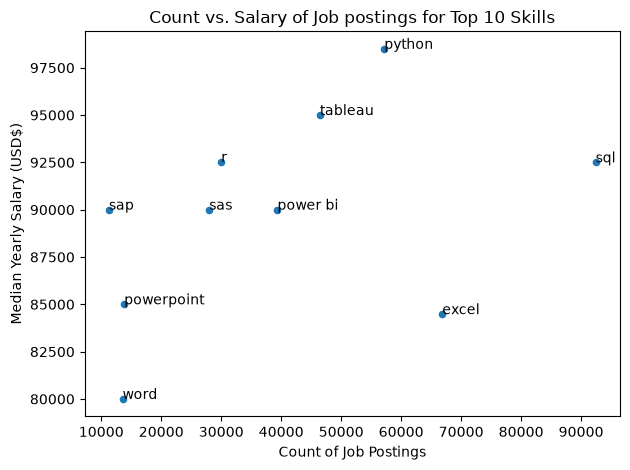

In [4]:
df = df[df['job_title_short']=='Data Analyst']
df_exploded = df.explode('job_skills')
skill_stats = df_exploded.groupby('job_skills').agg(
    skill_count = ('job_skills', 'count'),
    median_salary = ('salary_year_avg', 'median')
)
skill_stats = skill_stats.sort_values(by='skill_count', ascending=False).head(10)
skill_stats.plot(kind='scatter', x='skill_count', y='median_salary')
for i, text in enumerate(skill_stats.index):
    plt.text(skill_stats['skill_count'].iloc[i], skill_stats['median_salary'].iloc[i], text)
plt.title('Count vs. Salary of Job postings for Top 10 Skills')
plt.ylabel('Median Yearly Salary (USD$)')
plt.xlabel('Count of Job Postings')
plt.tight_layout()
plt.show()



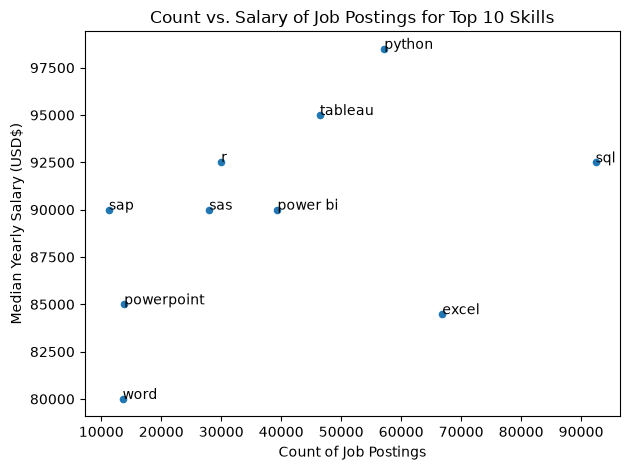

In [34]:
# prepare data >> groupby and sort df>> plot >> cleaning using for loop
df_DA = df[df['job_title_short']=='Data Analyst']
skill_stats = df_DA.explode('job_skills').groupby('job_skills').agg(
    skill_counts = ('job_skills', 'count'),
    median_salary = ('salary_year_avg', 'median')
).sort_values(by='skill_counts', ascending=False).head(10)
skill_stats.plot(kind='scatter', x='skill_counts', y='median_salary')
for i, text in enumerate(skill_stats.index):
    plt.text(skill_stats['skill_counts'].iloc[i], skill_stats['median_salary'].iloc[i], text)
plt.title('Count vs. Salary of Job Postings for Top 10 Skills')
plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary (USD$)')
plt.tight_layout()
plt.show()


In [31]:
skill_stats

,skill_counts,median_salary
job_skills,,
sql,92428,92500.0
excel,66860,84479.0
python,57190,98500.0
tableau,46455,95000.0
power bi,39380,90000.0
r,29996,92527.5
sas,27998,90000.0
powerpoint,13822,85000.0
word,13562,80000.0


In [20]:
skill_stats

,skill_counts,median_salary
job_skills,,
sql,92428,92500.0
excel,66860,84479.0
python,57190,98500.0
tableau,46455,95000.0
power bi,39380,90000.0
r,29996,92527.5
sas,27998,90000.0
powerpoint,13822,85000.0
word,13562,80000.0
